🏆 Final Model Comparison and Selection
📦 Loading all trained models...
❌ Random Forest not found
✅ Logistic Regression loaded


✅ LSTM model loaded

📊 Loading test data...

🎯 Evaluating all models on test set...


C:\Users\fukat\OneDrive\Desktop\fake-job-detector\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\fukat\OneDrive\Desktop\fake-job-detector\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\fukat\OneDrive\Desktop\fake-job-detector\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step

📊 FINAL MODEL COMPARISON

Logistic Regression:
  Accuracy:  0.9515
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

LSTM (Deep Learning):
  Accuracy:  0.9612
  Precision: 0.8095
  Recall:    0.2615
  F1-Score:  0.3953

🎉 BEST OVERALL MODEL: LSTM (Deep Learning)
   F1-Score: 0.3953

📈 Visual Comparison of Models


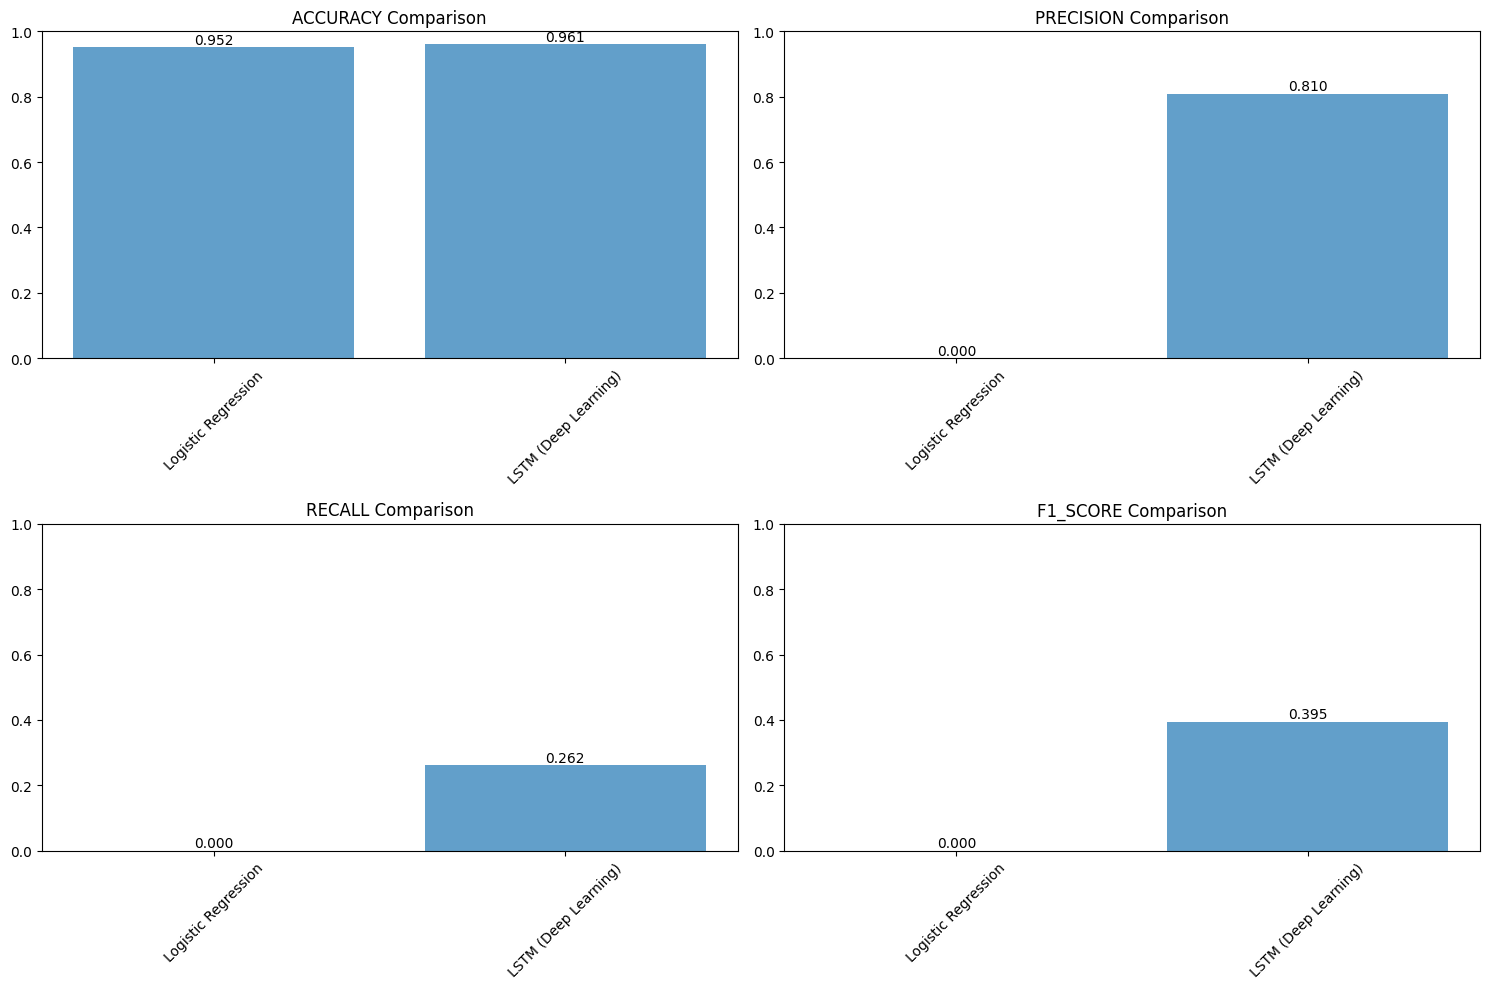


🔍 Detailed Analysis of LSTM (Deep Learning):

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2552
           1       0.81      0.26      0.40       130

    accuracy                           0.96      2682
   macro avg       0.89      0.63      0.69      2682
weighted avg       0.96      0.96      0.95      2682

Confusion Matrix:
[[2544    8]
 [  96   34]]

💼 Business Impact Analysis:
True Positives (Correctly caught fakes): 34
False Positives (Real jobs flagged as fake): 8
False Negatives (Missed fake jobs): 96
True Negatives (Correctly identified real jobs): 2544

💰 Cost Analysis:
- 8 real job seekers might be incorrectly rejected
- 96 fake jobs might go undetected
- 34 fake jobs successfully blocked
- 2544 real job seekers can safely apply

✅ Project Complete! 🎉
📋 Next: Deploy your best model or improve further!


In [1]:
# Final Model Comparison and Selection - Notebook 05
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.models import load_model

print("🏆 Final Model Comparison and Selection")
print("=" * 60)

# Load all models
print("📦 Loading all trained models...")

# Load basic ML models
try:
    rf_model = joblib.load('../models/random_forest_basic.pkl')
    print("✅ Random Forest loaded")
except:
    print("❌ Random Forest not found")
    rf_model = None

try:
    lr_model = joblib.load('../models/logistic_regression_basic.pkl')
    print("✅ Logistic Regression loaded")
except:
    print("❌ Logistic Regression not found")
    lr_model = None

# Load deep learning model
try:
    lstm_model = load_model('../models/lstm_text_model.h5')
    print("✅ LSTM model loaded")
except:
    print("❌ LSTM model not found")
    lstm_model = None

# Load test data
print("\n📊 Loading test data...")
test_data = pd.read_csv('../data/processed/test_data.csv')
X_test_numeric = test_data[['telecommuting', 'has_company_logo', 'has_questions']].values
y_test = test_data['fraudulent'].values

# Prepare text data for LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

text_columns = ['description', 'requirements', 'company_profile']
test_data['combined_text'] = test_data[text_columns].fillna('').apply(lambda x: ' '.join(x), axis=1)

# Load tokenizer (you might need to save/load this properly)
# For now, we'll create a simple version
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
train_data = pd.read_csv('../data/processed/train_data.csv')
train_data['combined_text'] = train_data[text_columns].fillna('').apply(lambda x: ' '.join(x), axis=1)
tokenizer.fit_on_texts(train_data['combined_text'])

X_test_text = tokenizer.texts_to_sequences(test_data['combined_text'])
X_test_text = pad_sequences(X_test_text, maxlen=200, padding='post', truncating='post')

# Evaluate all models
print("\n🎯 Evaluating all models on test set...")
results = {}

# Random Forest
if rf_model is not None:
    rf_pred = rf_model.predict(X_test_numeric)
    rf_accuracy = np.mean(rf_pred == y_test)
    rf_precision = classification_report(y_test, rf_pred, output_dict=True)['1']['precision']
    rf_recall = classification_report(y_test, rf_pred, output_dict=True)['1']['recall']
    rf_f1 = f1_score(y_test, rf_pred)
    
    results['Random Forest'] = {
        'accuracy': rf_accuracy,
        'precision': rf_precision,
        'recall': rf_recall,
        'f1_score': rf_f1
    }

# Logistic Regression
if lr_model is not None:
    lr_pred = lr_model.predict(X_test_numeric)
    lr_accuracy = np.mean(lr_pred == y_test)
    lr_precision = classification_report(y_test, lr_pred, output_dict=True)['1']['precision']
    lr_recall = classification_report(y_test, lr_pred, output_dict=True)['1']['recall']
    lr_f1 = f1_score(y_test, lr_pred)
    
    results['Logistic Regression'] = {
        'accuracy': lr_accuracy,
        'precision': lr_precision,
        'recall': lr_recall,
        'f1_score': lr_f1
    }

# LSTM Model
if lstm_model is not None:
    lstm_pred_proba = lstm_model.predict([X_test_text, X_test_numeric])
    lstm_pred = (lstm_pred_proba > 0.5).astype(int).flatten()
    
    lstm_accuracy = np.mean(lstm_pred == y_test)
    lstm_precision = classification_report(y_test, lstm_pred, output_dict=True)['1']['precision']
    lstm_recall = classification_report(y_test, lstm_pred, output_dict=True)['1']['recall']
    lstm_f1 = f1_score(y_test, lstm_pred)
    
    results['LSTM (Deep Learning)'] = {
        'accuracy': lstm_accuracy,
        'precision': lstm_precision,
        'recall': lstm_recall,
        'f1_score': lstm_f1
    }

# Display results
print("\n" + "=" * 60)
print("📊 FINAL MODEL COMPARISON")
print("=" * 60)

best_model = None
best_f1 = 0

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1_score']:.4f}")
    
    if metrics['f1_score'] > best_f1:
        best_f1 = metrics['f1_score']
        best_model = model_name

print(f"\n🎉 BEST OVERALL MODEL: {best_model}")
print(f"   F1-Score: {best_f1:.4f}")

# Visual comparison
print("\n📈 Visual Comparison of Models")
models = list(results.keys())
metrics_names = ['accuracy', 'precision', 'recall', 'f1_score']

plt.figure(figsize=(15, 10))

for i, metric in enumerate(metrics_names, 1):
    plt.subplot(2, 2, i)
    values = [results[model][metric] for model in models]
    plt.bar(models, values, alpha=0.7)
    plt.title(f'{metric.upper()} Comparison')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    
    # Add value labels
    for j, v in enumerate(values):
        plt.text(j, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

# Detailed analysis of best model
print(f"\n🔍 Detailed Analysis of {best_model}:")
if best_model == 'LSTM (Deep Learning)':
    y_pred = lstm_pred
else:
    y_pred = rf_pred if best_model == 'Random Forest' else lr_pred

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Business impact analysis
print("\n💼 Business Impact Analysis:")
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
total = len(y_test)

print(f"True Positives (Correctly caught fakes): {tp}")
print(f"False Positives (Real jobs flagged as fake): {fp}")
print(f"False Negatives (Missed fake jobs): {fn}")
print(f"True Negatives (Correctly identified real jobs): {tn}")

print(f"\n💰 Cost Analysis:")
print(f"- {fp} real job seekers might be incorrectly rejected")
print(f"- {fn} fake jobs might go undetected")
print(f"- {tp} fake jobs successfully blocked")
print(f"- {tn} real job seekers can safely apply")

print("\n" + "=" * 60)
print("✅ Project Complete! 🎉")
print("📋 Next: Deploy your best model or improve further!")